# A Comparative Evaluation of Gaussian Naive Bayes, Linear Discriminant Analysis and Quadratic Discriminant Analysis for Bank Term Deposit Prediction Under Class Imbalance

**Research Question**: How do the statistical assumptions of Gaussian Naive Bayes, Linear Discriminant Analysis and Quadratic Discriminant Analysis affect their predictive performance under class imbalance?

**Hypothesis**: Because all three models make different assumptions about feature distributions, feature independence and covariance structure, their predictive performance will differ.

### Explaining the Dataset

The data is related with direct marketing campaigns of a Portuguese banking institution. The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required, in order to assess if the product would be subscribed or not.

#### Bank client data:

- Age (numeric)
- Job : type of job (categorical: 'admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown')
- Marital : marital status (categorical: 'divorced', 'married', 'single', 'unknown' ; note: 'divorced' means divorced or widowed)
- Education (categorical: 'basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'illiterate', 'professional.course', 'university.degree', 'unknown')
- Default: has credit in default? (categorical: 'no', 'yes', 'unknown')
- Housing: has housing loan? (categorical: 'no', 'yes', 'unknown')
- Loan: has personal loan? (categorical: 'no', 'yes', 'unknown')

#### Other attributes:

- Campaign: number of contacts performed during this campaign and for
this client (numeric, includes last contact)
- Pdays: number of days that passed by after the client was last
contacted from a previous campaign (numeric; 999 means client was not
previously contacted)
- Previous: number of contacts performed before this campaign and for
this client (numeric)
- Poutcome: outcome of the previous marketing campaign (categorical:
'failure','nonexistent','success')

#### Social and economic context attributes

- Emp.var.rate: employment variation rate - quarterly indicator
(numeric)
- Cons.price.idx: consumer price index - monthly indicator (numeric)
- Cons.conf.idx: consumer confidence index - monthly indicator
(numeric)
- Euribor3m: euribor 3 month rate - daily indicator (numeric)
- Nr.employed: number of employees - quarterly indicator (numeric)

#### Output variable (desired target):

- y - has the client subscribed a term deposit? (binary: 'yes', 'no')


# Importing Libraries

In [1]:
import seaborn as sns
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

import warnings
from scipy.linalg import LinAlgWarning

warnings.filterwarnings("ignore", category=LinAlgWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
df = pd.read_csv("data/bank-additional-full.csv", sep=";")

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [5]:
df.shape

(41188, 21)

# Handling Missing Values

In [6]:
df[df == "unknown"].count()

age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

In [7]:
df = df.replace("unknown", np.nan)
df.isnull().sum()

age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

## Missing Values Visualization

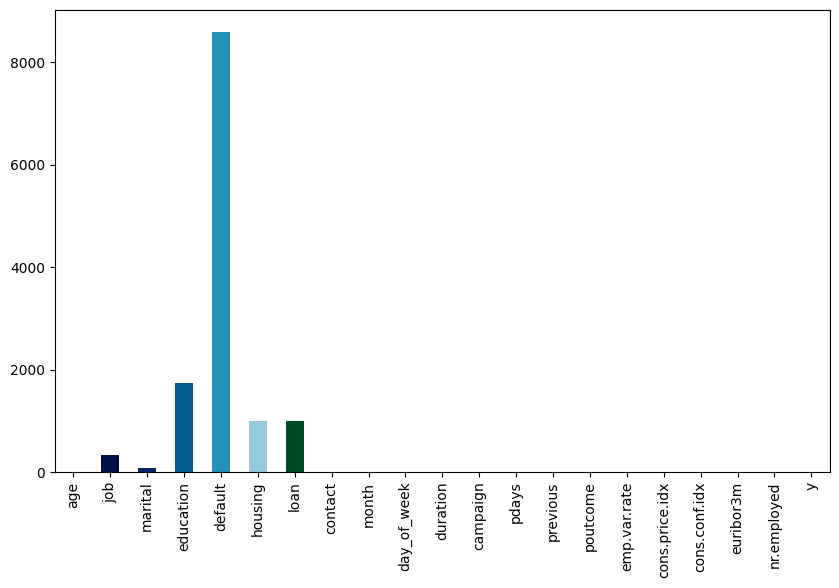

In [8]:
plt.figure(figsize=(10, 6))
df.isnull().sum().plot.bar(color=sns.color_palette("ocean"))
plt.show()

## Mode Imputation of Categorical Values

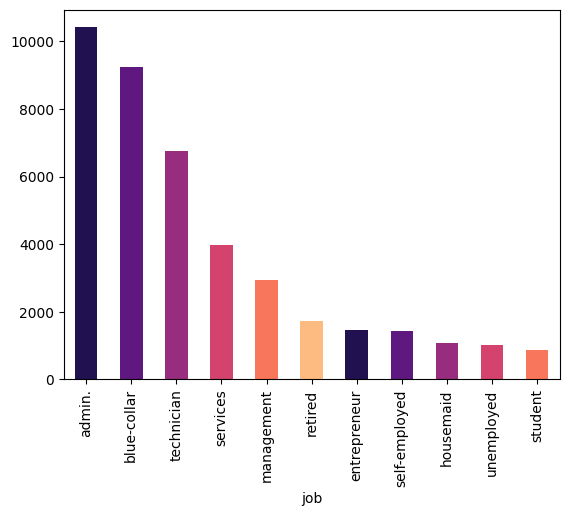

In [9]:
df["job"].value_counts().plot.bar(color=sns.color_palette("magma"))
plt.show()

In [10]:
df["job"] = df["job"].fillna(df["job"].mode()[0])

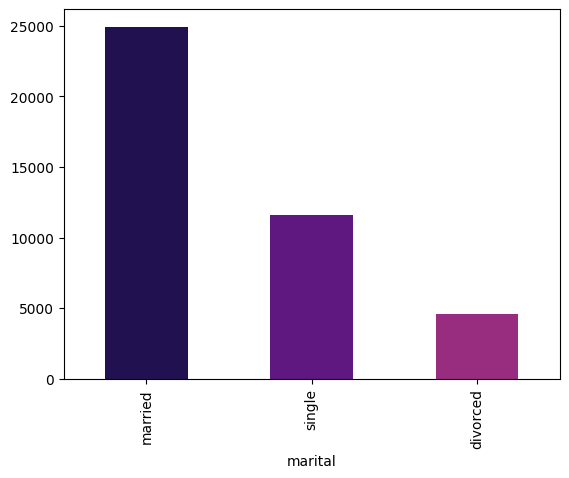

In [11]:
df["marital"].value_counts().plot.bar(color=sns.color_palette("magma"))
plt.show()

In [12]:
df["marital"] = df["marital"].fillna(df["marital"].mode()[0])

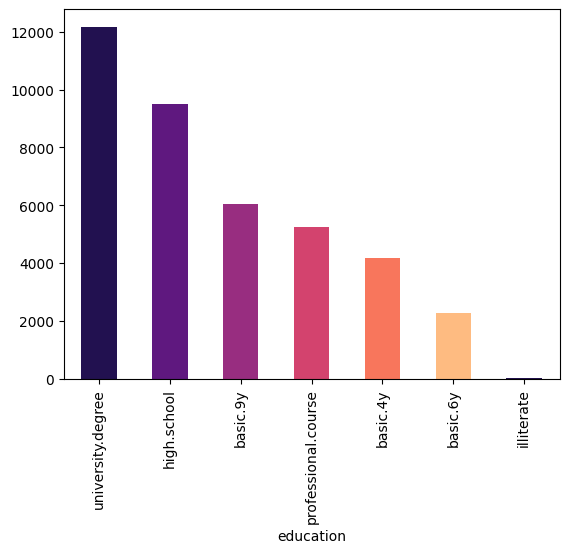

In [13]:
df["education"].value_counts().plot.bar(color=sns.color_palette("magma"))
plt.show()

In [14]:
df["education"] = df["education"].fillna(df["education"].mode()[0])

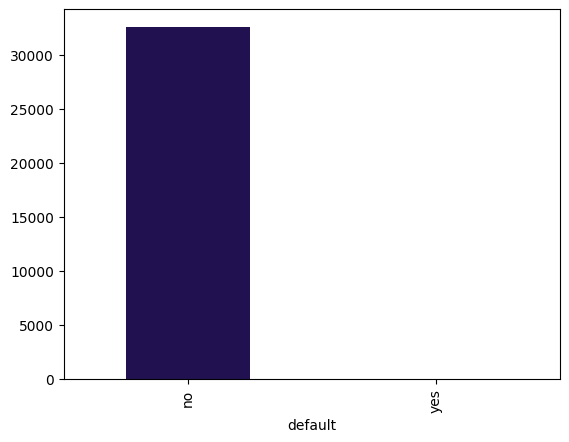

In [15]:
df["default"].value_counts().plot.bar(color=sns.color_palette("magma"))
plt.show()

In [16]:
df["default"] = df["default"].fillna(df["default"].mode()[0])

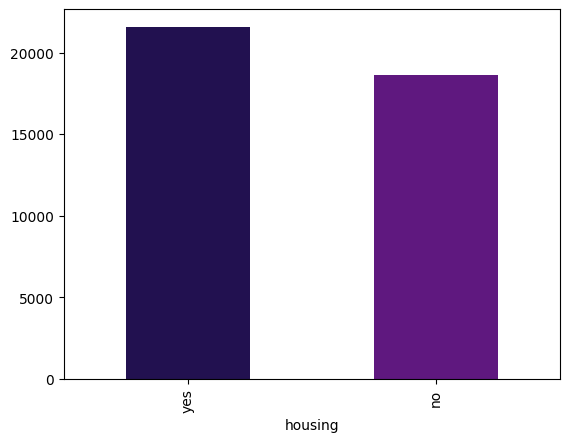

In [17]:
df["housing"].value_counts().plot.bar(color=sns.color_palette("magma"))
plt.show()

In [18]:
df["housing"] = df["housing"].fillna(df["housing"].mode()[0])

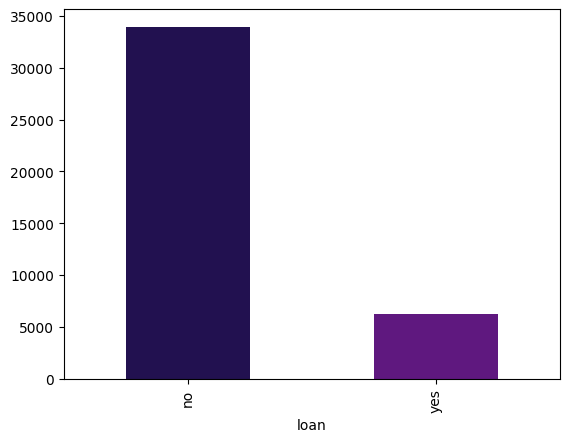

In [19]:
df["loan"].value_counts().plot.bar(color=sns.color_palette("magma"))
plt.show()

In [20]:
df["loan"] = df["loan"].fillna(df["loan"].mode()[0])

In [21]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

# Exploratory Data Analysis

The exploratory data analysis focuses on the characteristics of the input features and the distribution of the target variable.

In [22]:
df["y"].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

## Target Imbalance

The target ratio is 88.7% of the negative class against 11.3% of the positive class.

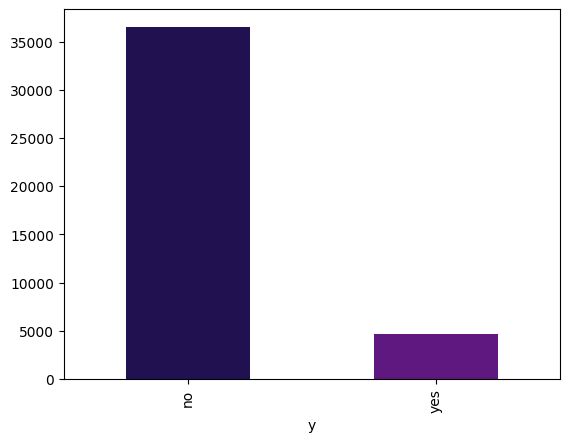

In [23]:
df["y"].value_counts().plot.bar(color=sns.color_palette("magma"))
plt.show()

## Pearson Correlation Matrix

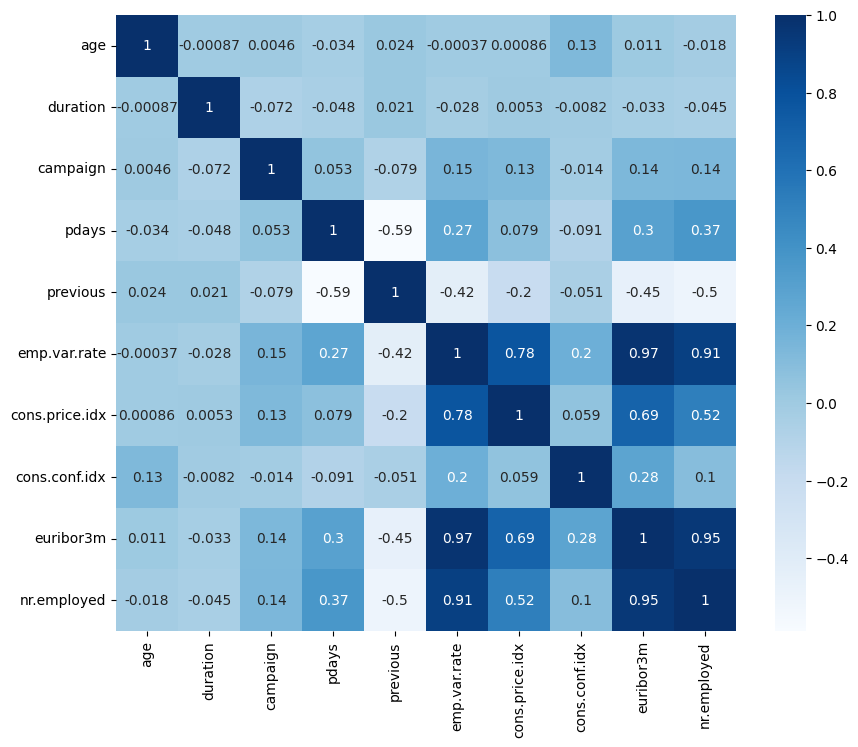

In [24]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), cmap="Blues", annot=True)
plt.show()

## Histograms for Numerical Features

**Age** is right-skewed, most clients are relatively young. **Duration** is strongly right-skewed, most calls are short. **Campaign** is strongly right-skewed, most clients were contacted only a few times. **Pdays** is bimodal, most values are around 999, so most clients were not previously contacted.

In [25]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

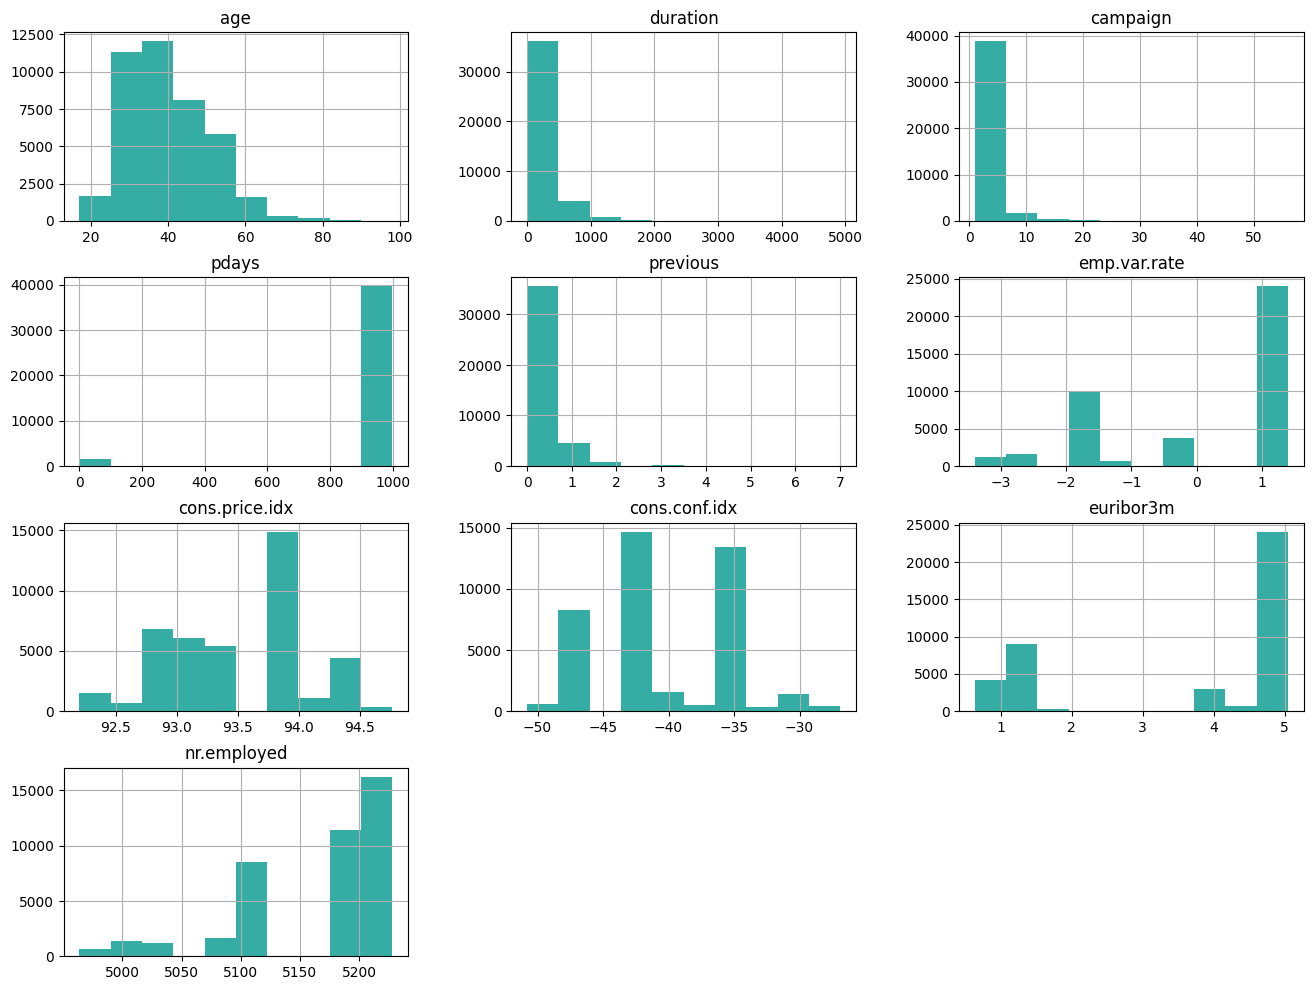

In [26]:
df[numerical_cols].hist(figsize=(16, 12), color=sns.color_palette("husl")[3])
plt.show()

## Bar Charts for Categorical Features

Most clients' **jobs** are administrators, blue-collar and technicians and the least were students. The majority of clients' **marital** status was married and the least were divorced. University degree is the largest **educational** category, followed by high school. Almost all clients have no credit in **default**. Most clients do not have a personal **loan**. The method of **contacting** clients was mostly cellular. Most clients didn't have a **previous campaign outcome**, while successful previous campaigns are uncommon.

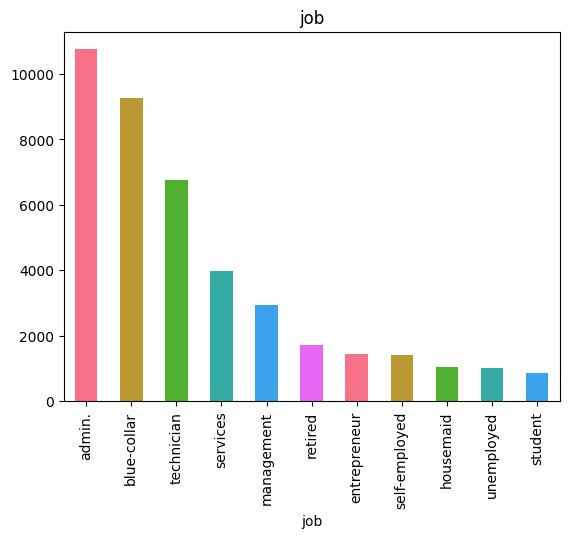

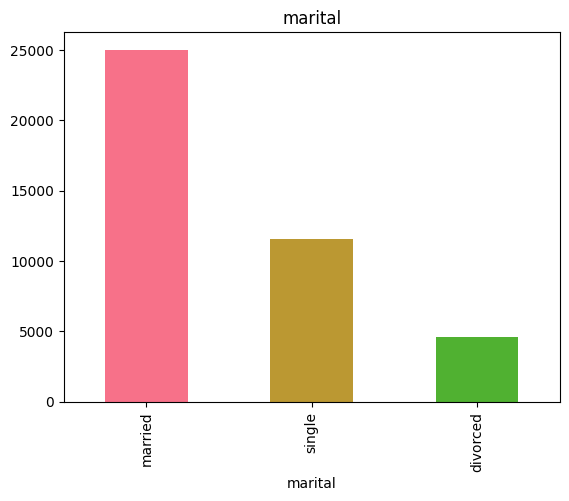

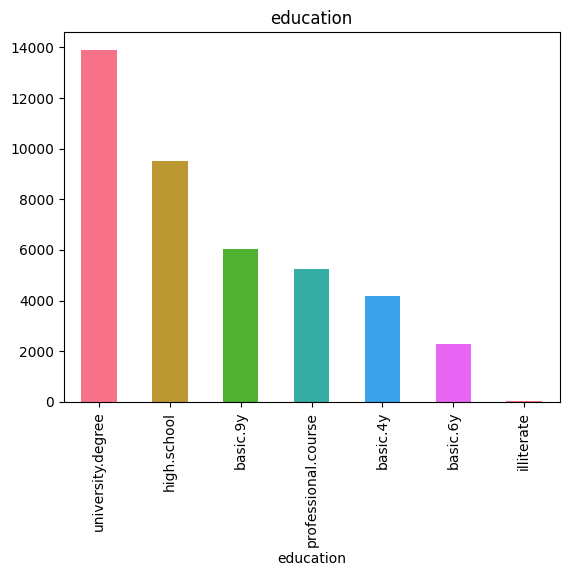

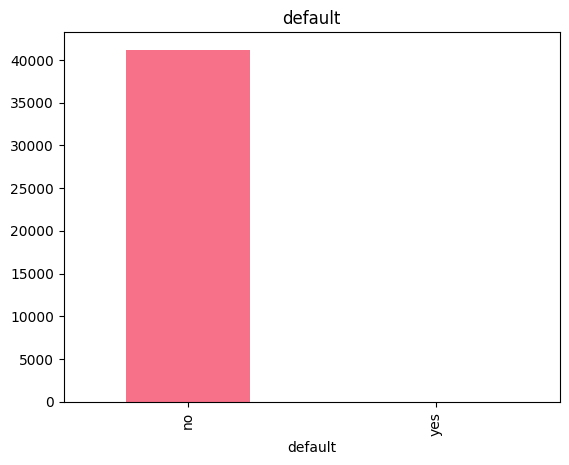

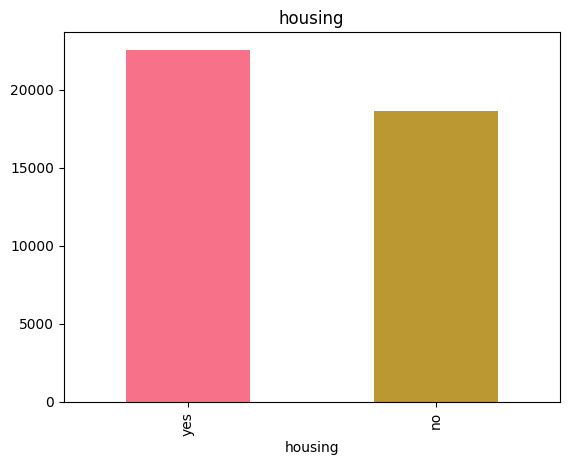

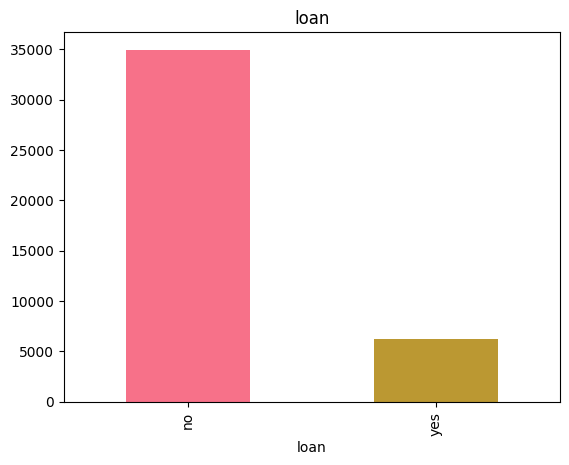

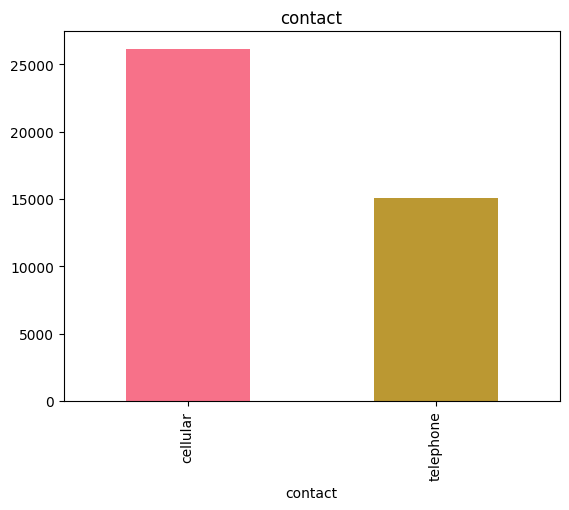

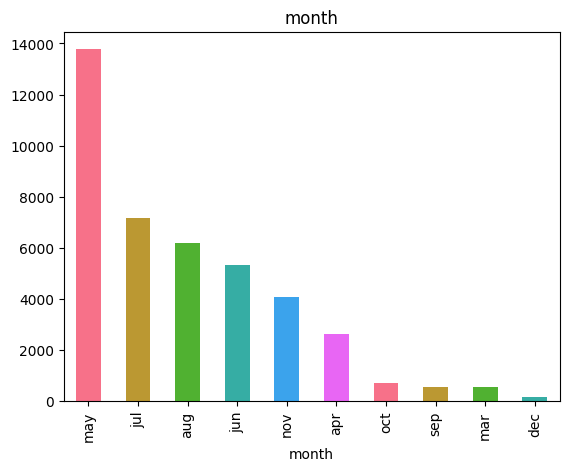

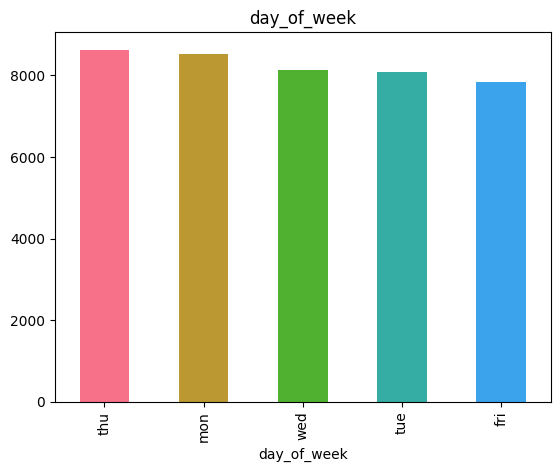

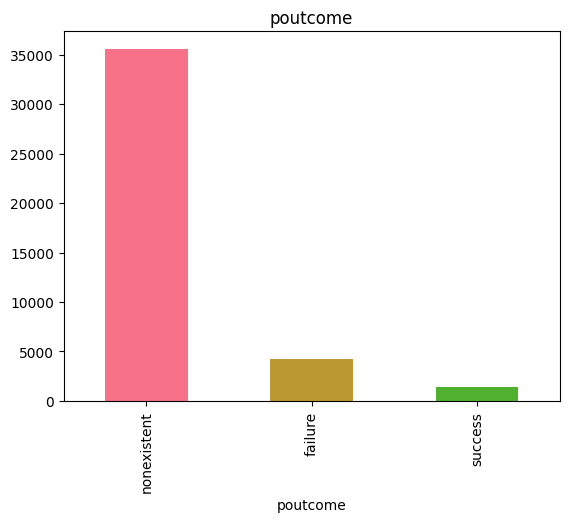

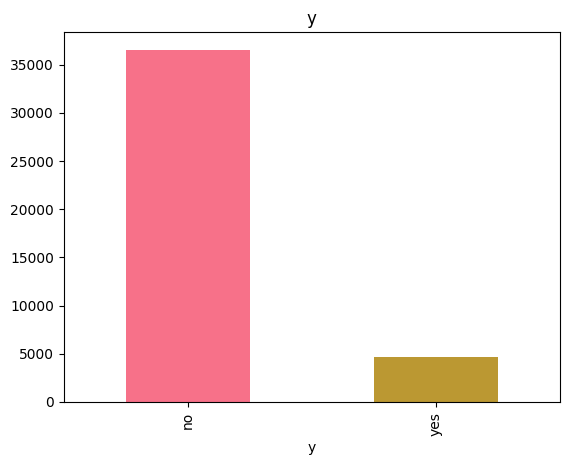

In [27]:
for col in cat_cols:
    plt.title(col)
    df[col].value_counts().plot.bar(color=sns.color_palette("husl"))
    plt.show()

## Box Plots for Quantiles and Outliers

**Age** median is around 37, middle 50% is around 31-45, older clients are outliers. Most call **durations** are short, small number of calls are extremely long. Most clients were not contacted previously, most number of **pdays** after the client was last contacted is concentrated around 999.

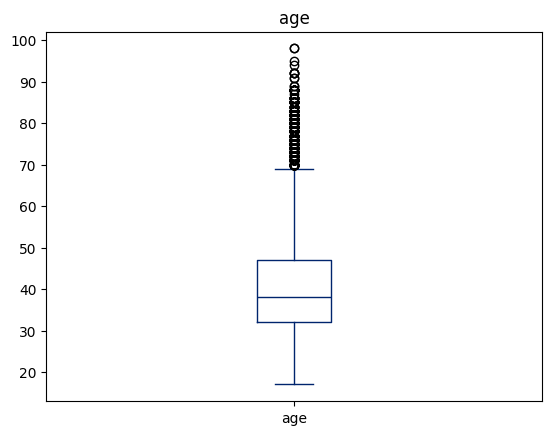

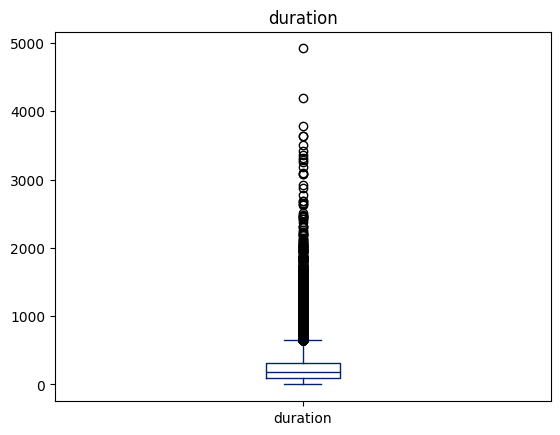

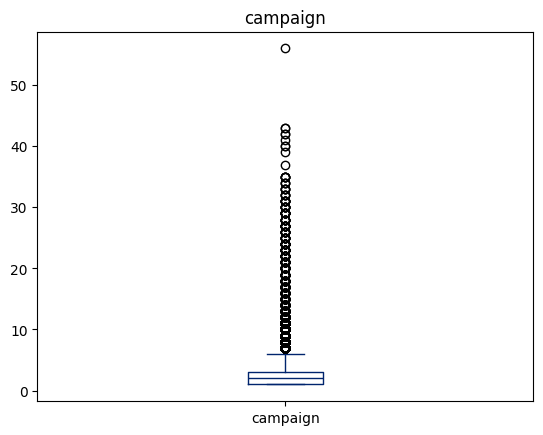

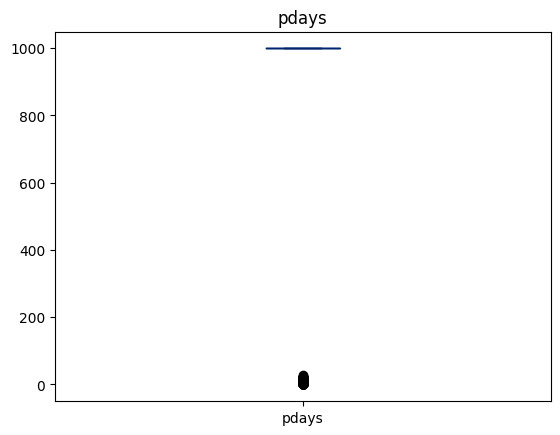

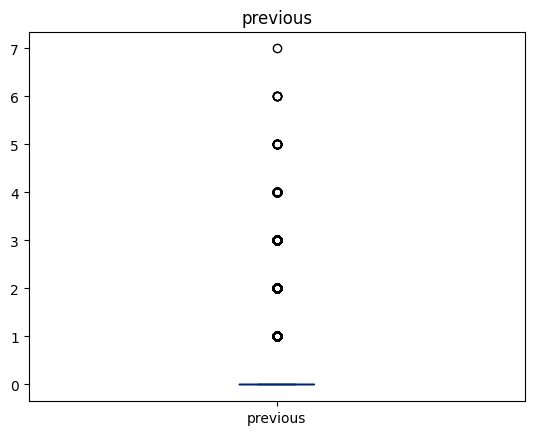

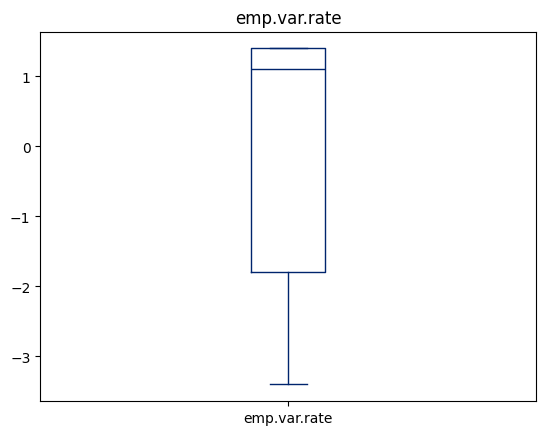

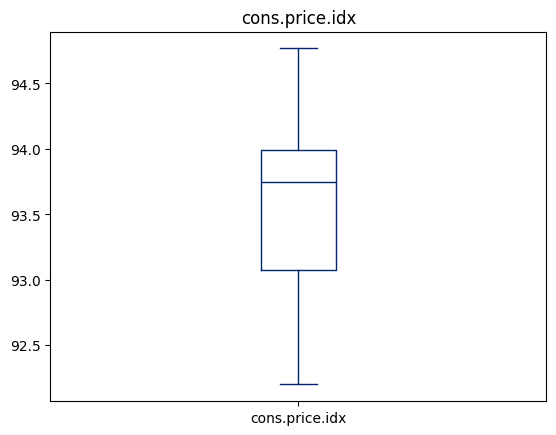

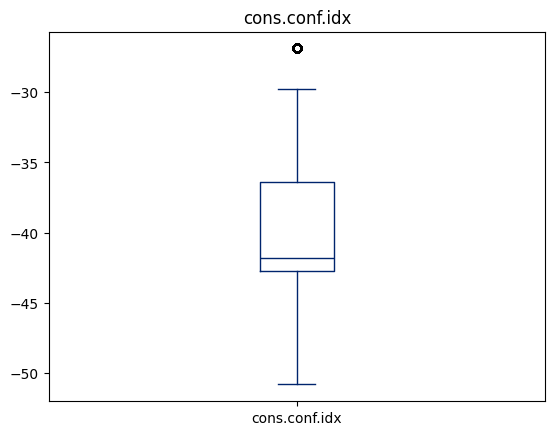

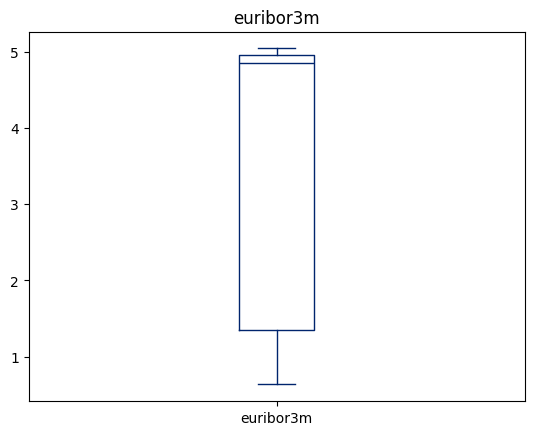

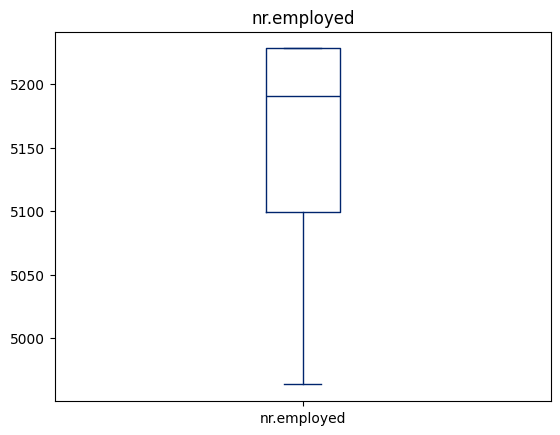

In [28]:
for col in numerical_cols:
    plt.title(col)
    df[col].plot.box(color=sns.color_palette("ocean")[2])
    plt.show()

## Violin Plots for Numerical Features

We can conclude that subscribers have wider age distribution towards older ages, suggesting that older clients were more represented among those who subscribed. Clients who subscribed tended to have longer phone calls than clients who did not subscribe.

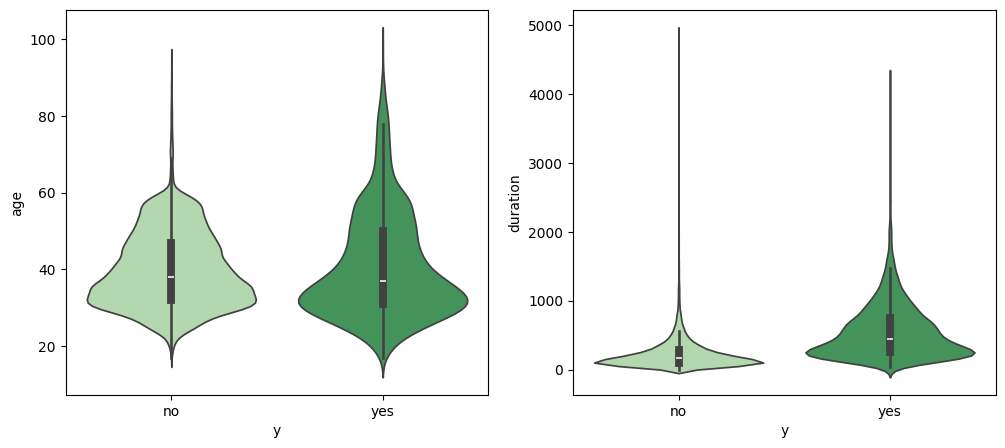

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.violinplot(data=df, x="y", y="age", hue="y", palette="Greens", ax=axes[0])
sns.violinplot(data=df, x="y", y="duration", hue="y", palette="Greens", ax=axes[1])

plt.show()

In [30]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# Multicollinearity Check

We conclude strong positive correlation between:
- **euribor3m** and **nr.employed**
- **euribor3m** and **emp.var.rate**
- **emp.var.rate** and **nr.employed**

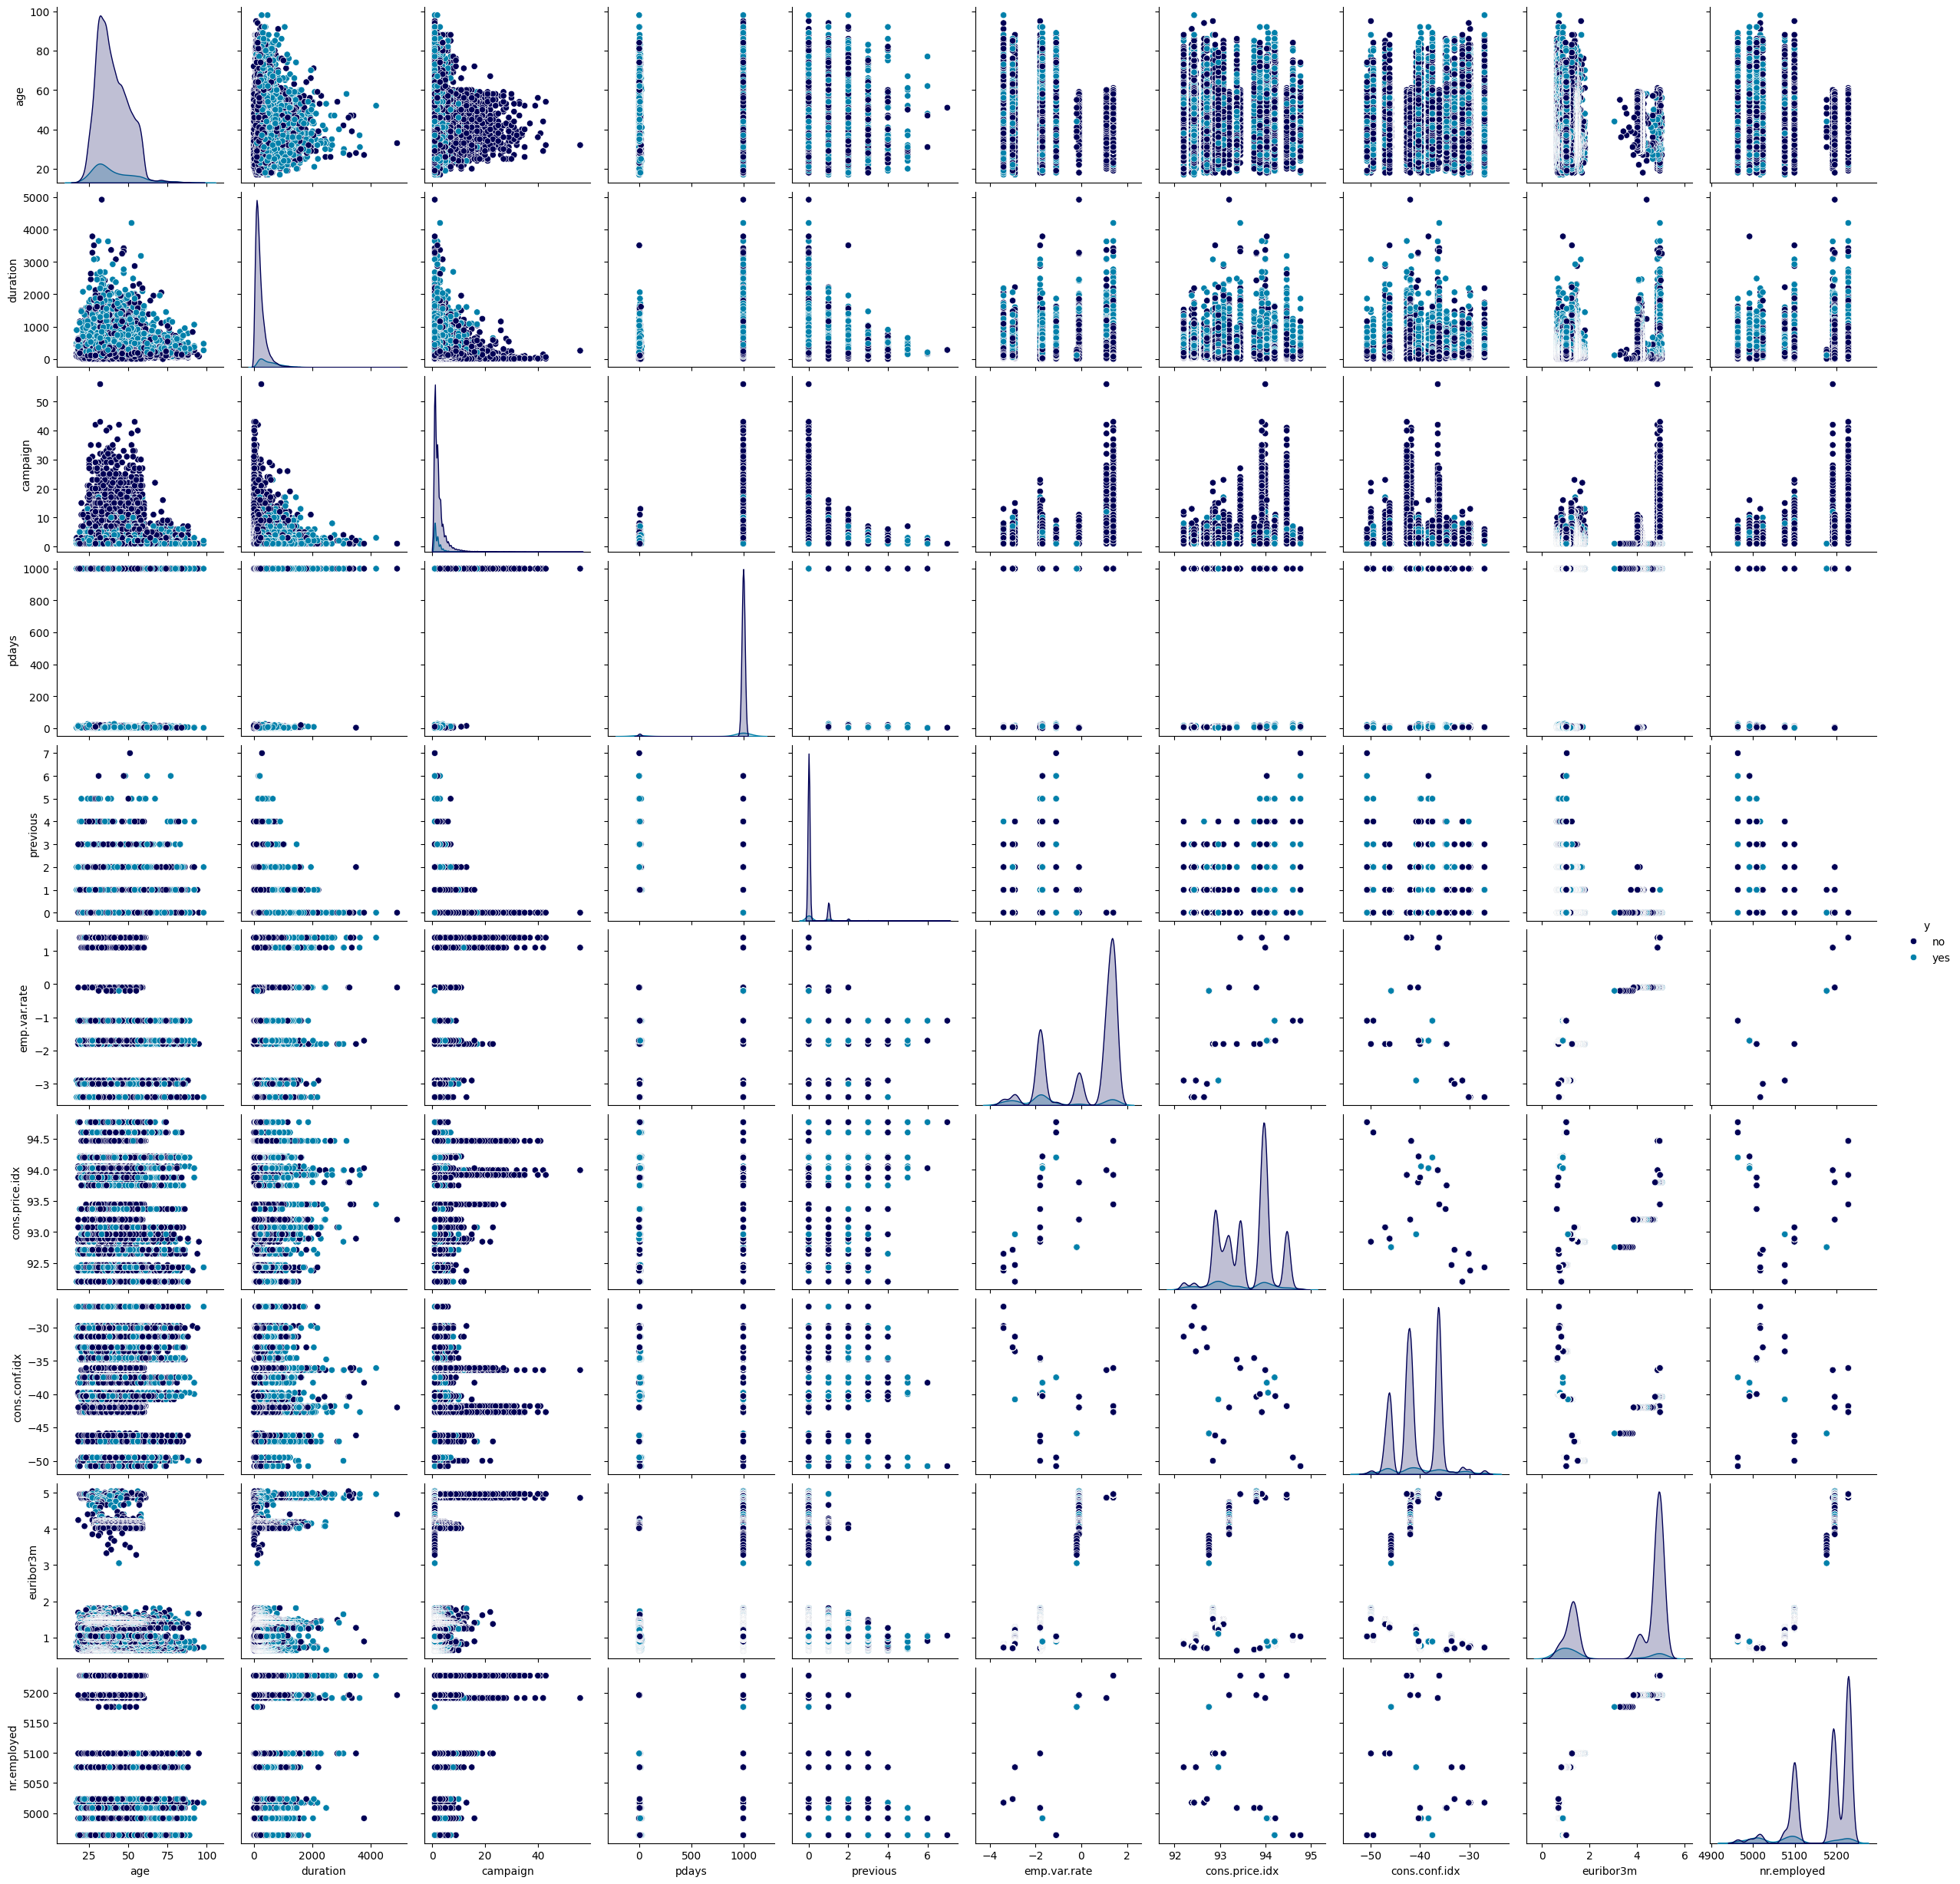

In [31]:
sns.pairplot(df, hue="y", palette="ocean", diag_kind="kde")
plt.show()

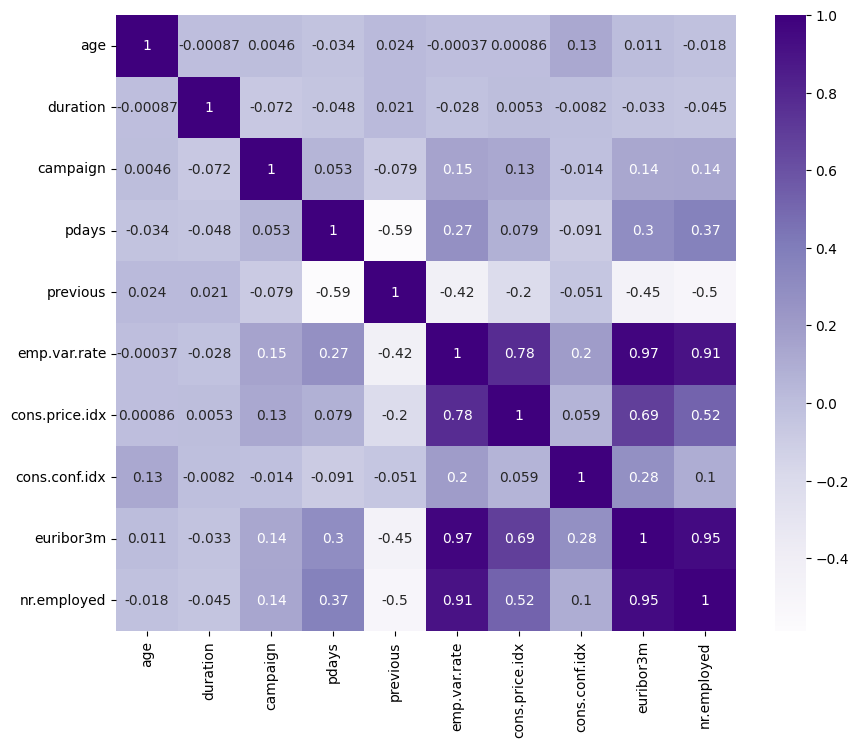

In [31]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), cmap="Purples", annot=True)
plt.show()

## Removing Mutually Correlated Features

In [32]:
df = df.drop(columns=["emp.var.rate", "euribor3m"])

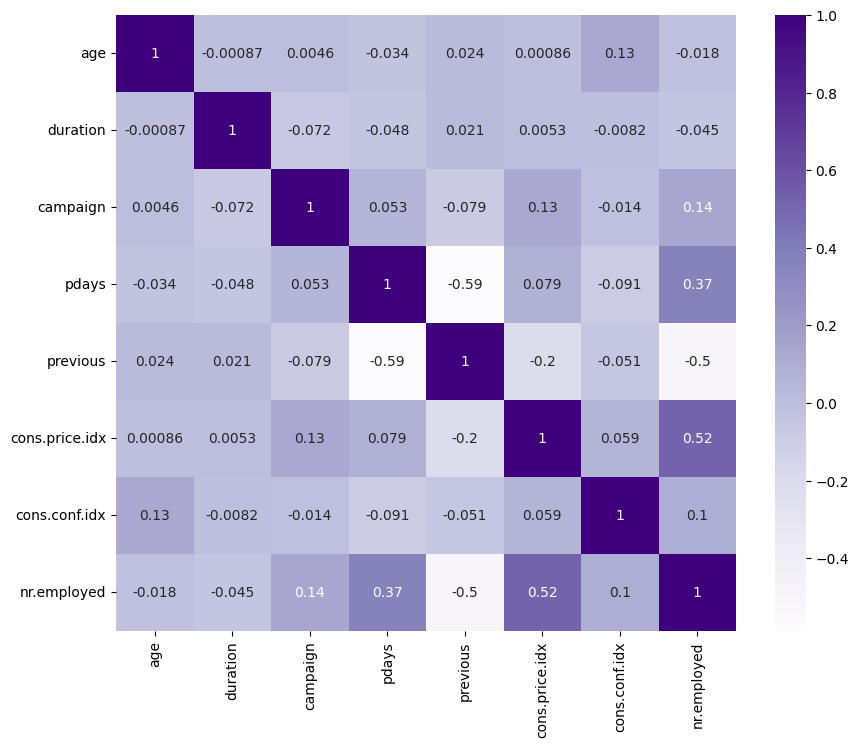

In [33]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), cmap="Purples", annot=True)
plt.show()

# Categorical Encoding

## Ordinal Values

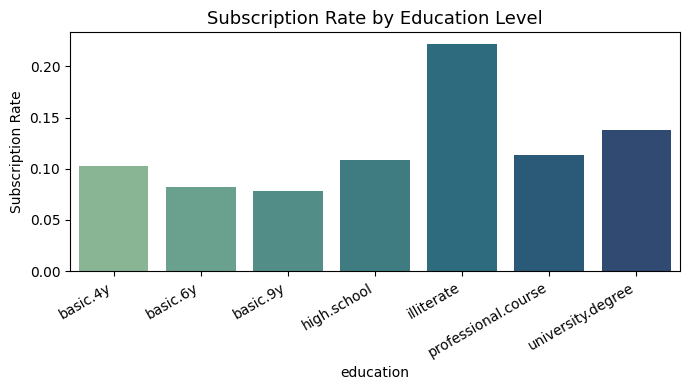

In [34]:
plt.figure(figsize=(7, 4))

rates = df.groupby("education")["y"].apply(lambda s: (s == "yes").mean())
sns.barplot(x=rates.index, y=rates.values, hue=rates.index, palette="crest", legend=False)

plt.title("Subscription Rate by Education Level", fontsize=13)
plt.ylabel("Subscription Rate")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

The subscription rate was highest among clients with **illiterate** education level.

In [35]:
df["education"].value_counts()

education
university.degree      13899
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
illiterate                18
Name: count, dtype: int64

In [36]:
encoder = OrdinalEncoder(categories=[["illiterate", "basic.4y", "basic.6y", 
                                      "basic.9y", "high.school", "professional.course", 
                                      "university.degree"]])

df["education"] = encoder.fit_transform(df[["education"]])

df["education"].value_counts()

education
6.0    13899
4.0     9515
3.0     6045
5.0     5243
1.0     4176
2.0     2292
0.0       18
Name: count, dtype: int64

## Nominal Values

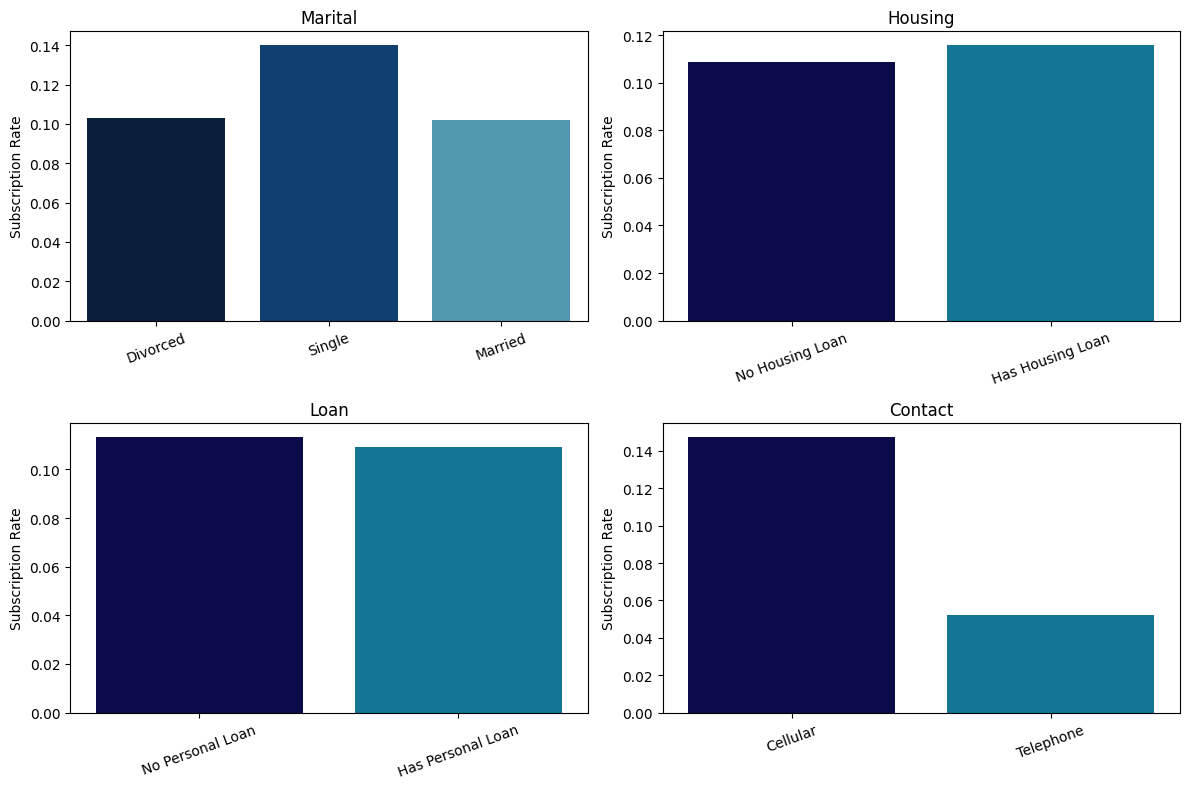

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

nominal_specs = [
    ("marital", ["divorced", "single", "married"], ["Divorced", "Single", "Married"]),
    ("housing", ["no", "yes"], ["No Housing Loan", "Has Housing Loan"]),
    ("loan", ["no", "yes"], ["No Personal Loan", "Has Personal Loan"]),
    ("contact", ["cellular", "telephone"], ["Cellular", "Telephone"])
]

for ax, (col, order, labels) in zip(axes.flat, nominal_specs):
    rates = df.groupby(col)["y"].apply(lambda s: (s == "yes").mean()).reindex(order)
    sns.barplot(x=labels, y=rates.values, hue=labels, palette="ocean", legend=False, ax=ax)
    ax.set_title(col.capitalize())
    ax.set_ylabel("Subscription Rate")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

The subscription rate was highest among **single** clients and clients contacted by **cellular**.

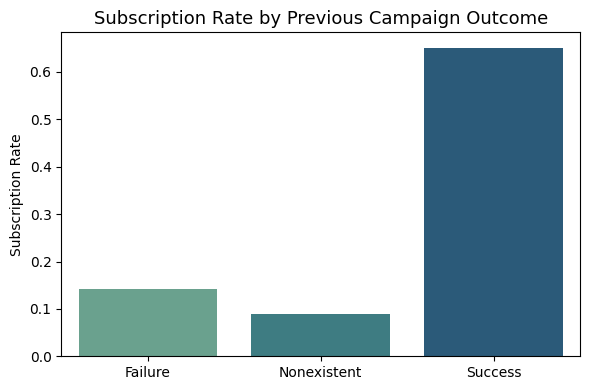

In [38]:
plt.figure(figsize=(6, 4))

order = ["failure", "nonexistent", "success"]
labels = ["Failure", "Nonexistent", "Success"]

rates = df.groupby("poutcome")["y"].apply(lambda s: (s == "yes").mean()).reindex(order)

sns.barplot(x=labels, y=rates.values, hue=labels, palette="crest", legend=False)

plt.title("Subscription Rate by Previous Campaign Outcome", fontsize=13)
plt.ylabel("Subscription Rate")
plt.tight_layout()
plt.show()

Clients with a **successful** previous campaign outcome have a higher subscription rate than those with a failed or nonexistent outcome, indicating that **poutcome** is an important predictive feature.

In [39]:
df["poutcome"].value_counts()

poutcome
nonexistent    35563
failure         4252
success         1373
Name: count, dtype: int64

In [40]:
df = pd.get_dummies(df, columns=["poutcome"])

In [41]:
df["marital"].value_counts()

marital
married     25008
single      11568
divorced     4612
Name: count, dtype: int64

In [42]:
df = pd.get_dummies(df, columns=["marital"])

In [43]:
df["housing"].value_counts()

housing
yes    22566
no     18622
Name: count, dtype: int64

In [44]:
df = pd.get_dummies(df, columns=["housing"])

In [45]:
df["loan"].value_counts()

loan
no     34940
yes     6248
Name: count, dtype: int64

In [46]:
df = pd.get_dummies(df, columns=["loan"])

In [47]:
df["contact"].value_counts()

contact
cellular     26144
telephone    15044
Name: count, dtype: int64

In [48]:
df = pd.get_dummies(df, columns=["contact"])

In [49]:
df["y"] = df["y"].map({"yes": 1, "no": 0})

# Feature Selection

## Low Variability

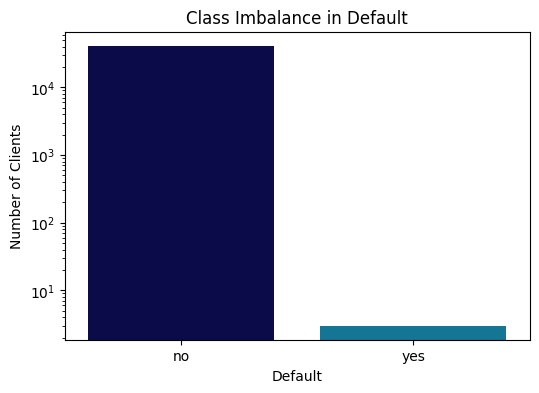

In [50]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="default", hue="default", palette="ocean", legend=False)

plt.title("Class Imbalance in Default")
plt.xlabel("Default")
plt.ylabel("Number of Clients")

plt.yscale("log")
plt.show()

In [51]:
df = df.drop(columns="default")

## Dimensionality Reduction

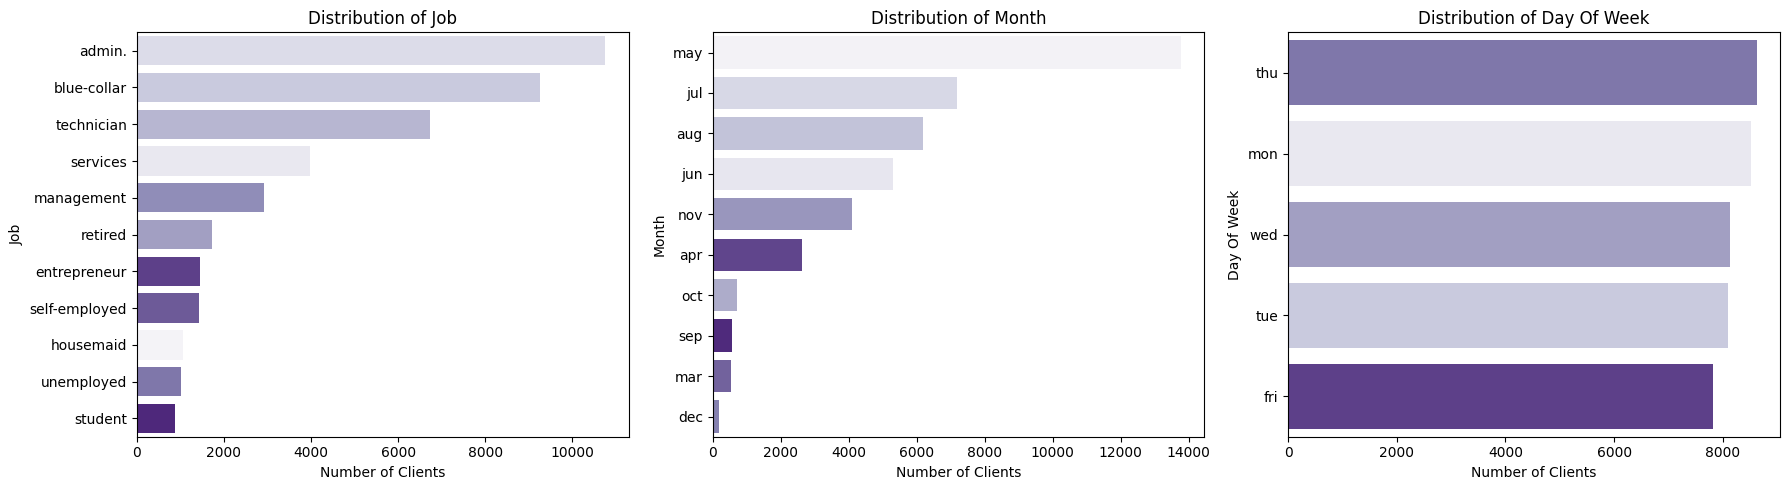

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

categorical_features = ["job", "month", "day_of_week"]

for ax, feature in zip(axes, categorical_features):
    order = df[feature].value_counts().index
    
    sns.countplot(data=df, y=feature, order=order, hue=feature, palette="Purples", legend=False, ax=ax)
    
    ax.set_title(f"Distribution of {feature.replace('_', ' ').title()}")
    ax.set_xlabel("Number of Clients")
    ax.set_ylabel(feature.replace("_", " ").title())

plt.tight_layout()
plt.show()

In [53]:
df = df.drop(columns=["job", "month", "day_of_week"])

In [54]:
df.dtypes

age                       int64
education               float64
duration                  int64
campaign                  int64
pdays                     int64
previous                  int64
cons.price.idx          float64
cons.conf.idx           float64
nr.employed             float64
y                         int64
poutcome_failure           bool
poutcome_nonexistent       bool
poutcome_success           bool
marital_divorced           bool
marital_married            bool
marital_single             bool
housing_no                 bool
housing_yes                bool
loan_no                    bool
loan_yes                   bool
contact_cellular           bool
contact_telephone          bool
dtype: object

## Removing Redundant One-Hot Columns

We can see perfect correlations of **-1** between **housing_no** and **housing_yes**, **loan_no** and **loan_yes**, **contact_cellular** and **contact_telephone**. They are mutually exclusive. For **marital status** and **poutcome** we can keep two out of the three one-hot categories.

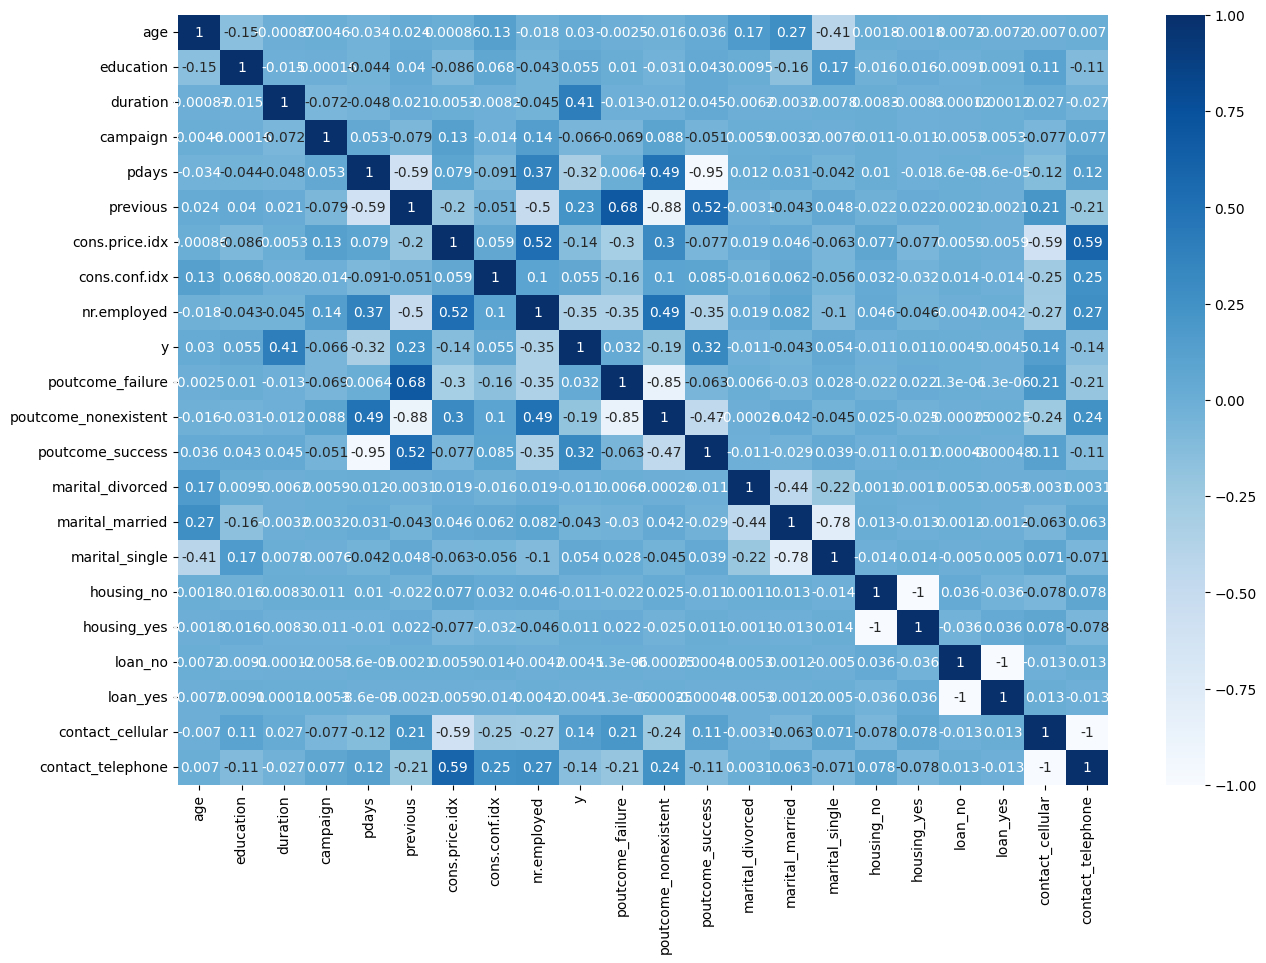

In [55]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")
plt.show()

In [56]:
df = df.drop(columns=["housing_no", "loan_no", "contact_telephone", "marital_married", "poutcome_nonexistent"])

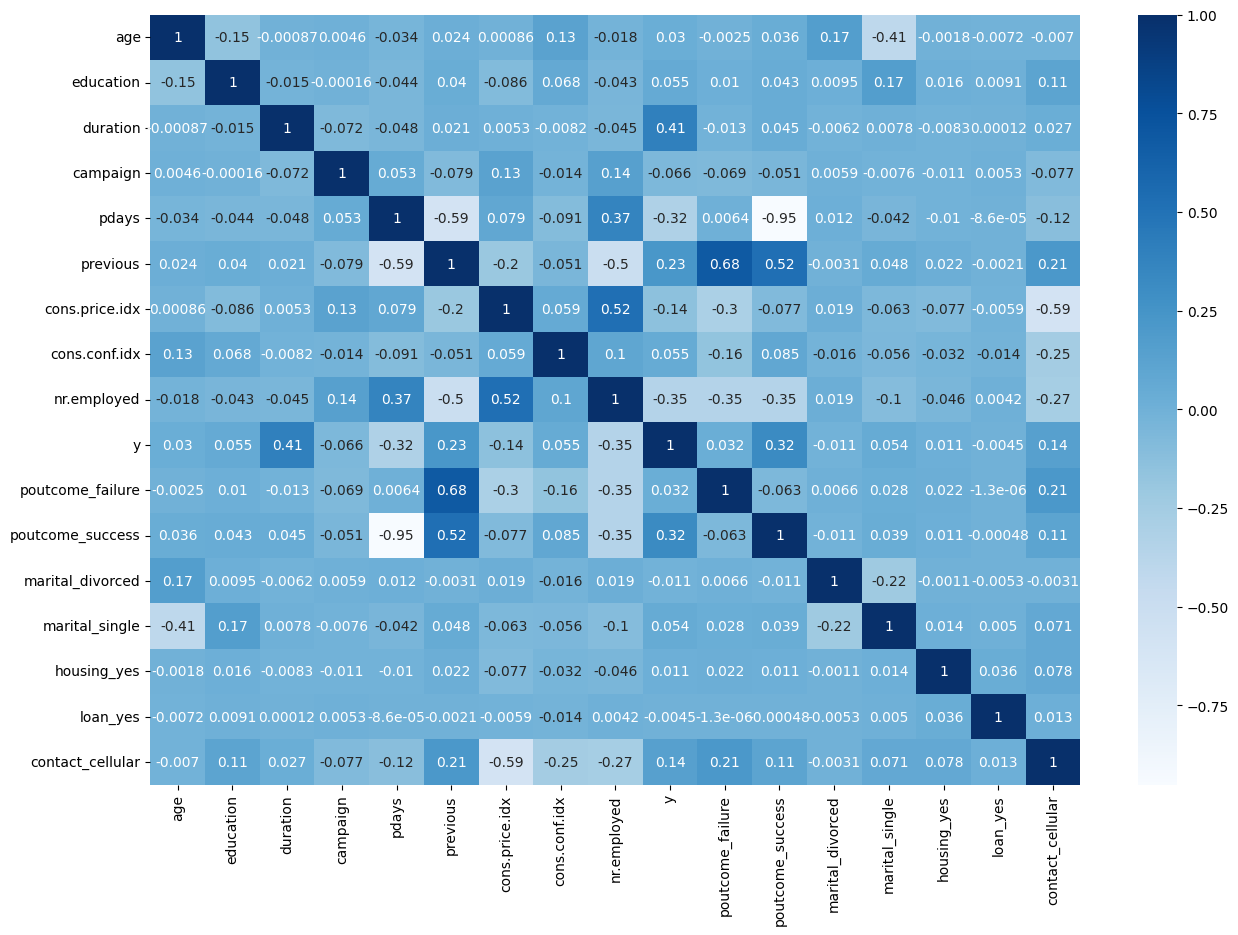

In [57]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")
plt.show()

## Data Leakage

The intended use of this model is to predict whether a client should be contacted, so call duration would not exist at prediction time.

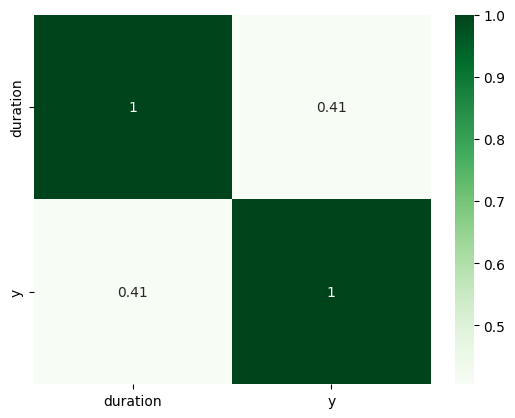

In [58]:
sns.heatmap(df[["duration", "y"]].corr(), annot=True, cmap="Greens")
plt.show()

In [59]:
df = df.drop(columns="duration")

## Train-Test Split

In [60]:
X, y = df.drop(columns="y"), df["y"]

In [61]:
train_X, test_X, train_y, test_y = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [62]:
train_X.shape, test_X.shape

((32950, 15), (8238, 15))

## Feature Normalization

In [63]:
scaler = StandardScaler()
train_X = scaler.fit_transform(train_X)
test_X = scaler.transform(test_X)

## Multiple Model Testing 

In [64]:
def model_trial(model_name, model):
    model.fit(train_X, train_y)

    pred_y = model.predict(test_X)
    
    plt.figure(figsize=(6, 4))
    cm = confusion_matrix(test_y, pred_y)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
    plt.title(model_name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print()
    print()
    print(classification_report(test_y, pred_y))

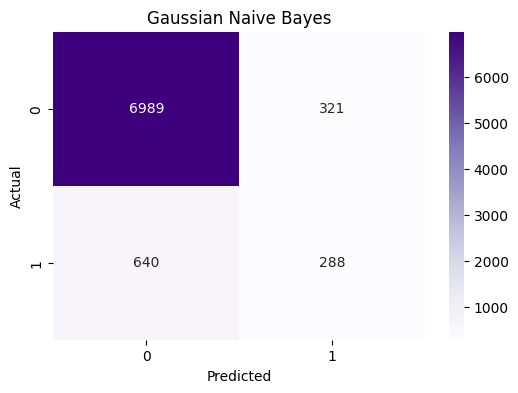



              precision    recall  f1-score   support

           0       0.92      0.96      0.94      7310
           1       0.47      0.31      0.37       928

    accuracy                           0.88      8238
   macro avg       0.69      0.63      0.66      8238
weighted avg       0.87      0.88      0.87      8238



In [65]:
model_trial("Gaussian Naive Bayes", GaussianNB())

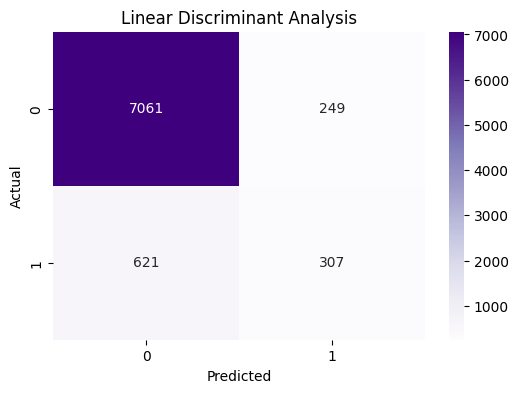



              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7310
           1       0.55      0.33      0.41       928

    accuracy                           0.89      8238
   macro avg       0.74      0.65      0.68      8238
weighted avg       0.88      0.89      0.88      8238



In [66]:
model_trial("Linear Discriminant Analysis", LinearDiscriminantAnalysis())

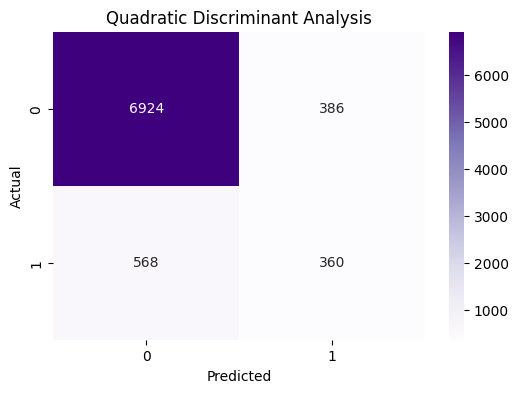



              precision    recall  f1-score   support

           0       0.92      0.95      0.94      7310
           1       0.48      0.39      0.43       928

    accuracy                           0.88      8238
   macro avg       0.70      0.67      0.68      8238
weighted avg       0.87      0.88      0.88      8238



In [67]:
model_trial("Quadratic Discriminant Analysis", QuadraticDiscriminantAnalysis())

## Model Performance With Undersampling

Because the target variable is highly imbalanced, accuracy alone does not represent model performance. A classifier could achieve high accuracy by just predicting the majority class.

In [68]:
X, y = df.drop(columns=["y"]), df["y"]

In [69]:
train_X, test_X, train_y, test_y = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [70]:
train_y.value_counts()

y
0    29238
1     3712
Name: count, dtype: int64

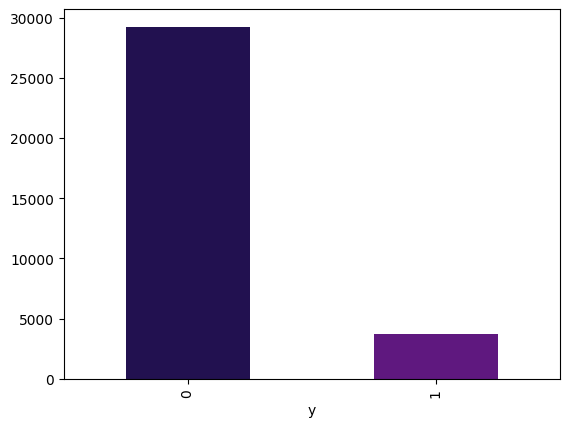

In [71]:
train_y.value_counts().plot.bar(color=sns.color_palette("magma"))
plt.show()

In [72]:
train = pd.concat([train_X, train_y], axis=1)

train = pd.concat([
    train[train.y == 0].sample(3712, random_state=42),
    train[train.y == 1]
]).sample(frac=1, random_state=42)

train_X = train.drop(columns=["y"])
train_y = train.y

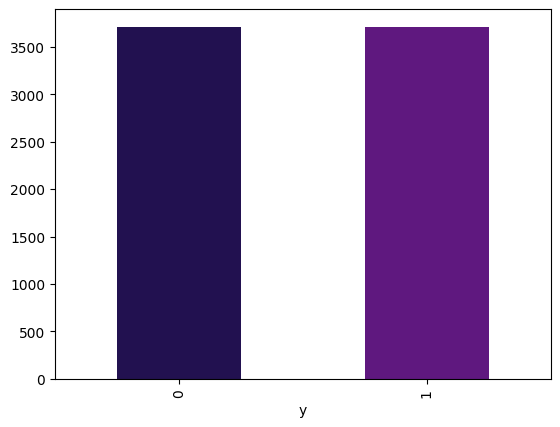

In [73]:
train_y.value_counts().plot.bar(color=sns.color_palette("magma"))
plt.show()

In [74]:
scaler = StandardScaler()
train_X = scaler.fit_transform(train_X)
test_X = scaler.transform(test_X)

In [75]:
train_X.shape, train_y.shape

((7424, 15), (7424,))

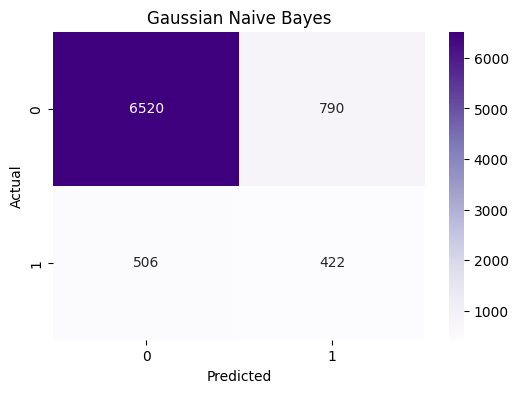



              precision    recall  f1-score   support

           0       0.93      0.89      0.91      7310
           1       0.35      0.45      0.39       928

    accuracy                           0.84      8238
   macro avg       0.64      0.67      0.65      8238
weighted avg       0.86      0.84      0.85      8238



In [76]:
model_trial("Gaussian Naive Bayes", GaussianNB())

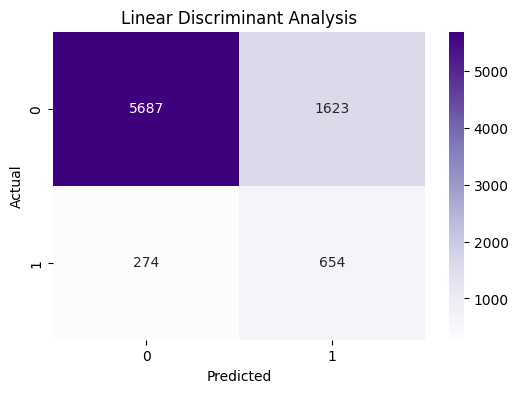



              precision    recall  f1-score   support

           0       0.95      0.78      0.86      7310
           1       0.29      0.70      0.41       928

    accuracy                           0.77      8238
   macro avg       0.62      0.74      0.63      8238
weighted avg       0.88      0.77      0.81      8238



In [77]:
model_trial("Linear Discriminant Analysis", LinearDiscriminantAnalysis())

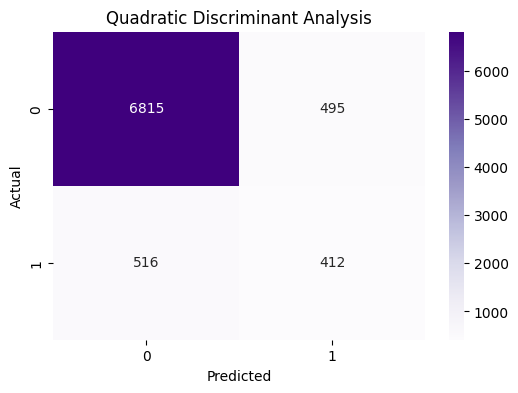



              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7310
           1       0.45      0.44      0.45       928

    accuracy                           0.88      8238
   macro avg       0.69      0.69      0.69      8238
weighted avg       0.88      0.88      0.88      8238



In [78]:
model_trial("Quadratic Discriminant Analysis", QuadraticDiscriminantAnalysis())

# Conclusion

**Gaussian Naive Bayes** assumes that each feature follows a **Gaussian distribution** and that the features are **conditionally independent** given the class. This is a strong assumption and often unrealistic for real-world data. **Linear Discriminant Analysis** assumes that within each class, the predictors follow a **Gaussian distribution** with a **shared covariance matrix**. **Quadratic Discriminant Analysis** is more flexible because it allows a **separate covariance matrix** for each class, but this can make it more sensitive to overfitting.

<h3 align="center">Gaussian Naive Bayes</h3>

$$
P(y \mid X) =
\frac{P(y)\prod_{i=1}^{n}P(x_i\mid y)}
{P(X)}
$$

<h3 align="center">Linear Discriminant Analysis</h3>

$$
\Sigma_1 = \Sigma_2 = \cdots = \Sigma_k = \Sigma
$$

<h3 align="center">Quadratic Discriminant Analysis</h3>

$$
\Sigma_1 \neq \Sigma_2 \neq \cdots \neq \Sigma_k
$$
<br/>

The imbalanced dataset produces **high overall accuracy** while minority-class **recall remains low**. After undersampling, minority-class recall increases for all three models, while overall accuracy differs between models.

**Linear Discriminant Analysis** had the most substantial change, with an increase in minority-class recall from **0.33** to **0.70**, while accuracy decreased from **0.89** to **0.77**.

**Quadratic Discriminant Analysis** had the most stable results, accuracy remaining **0.88**, with minority-class recall increase from **0.39** to **0.44**.

**Gaussian Naive Bayes** experienced a decrease in accuracy from **0.88** to **0.84** and a jump in minority-class recall from **0.31** to **0.45**.

**Note**: A limitation is that the one-hot encoded categorical variables are binary and therefore do not follow a Gaussian distribution per the assumptions of the models.

<p style="text-align: right;"><b>Nina Trifunovska</b></p>